In [16]:
# ============================================================
# PFE Baseline: Pretrained ViT (timm) on CIFAR-10 (PyTorch)
# Uses vit_small_patch16_224 pretrained on ImageNet-21k
#
# KEY DESIGN DECISION — no upscaling, native 32×32:
#   Like ResNet-50 (modified conv1 + removed maxpool),
#   we adapt the ViT architecture to 32×32 rather than
#   resizing inputs to 224×224.
#
#   patch_size=16 on 32×32 → only 4 patches (2×2): too coarse.
#   Solution: use patch_size=4 → 64 patches (8×8 grid).
#
#   timm supports this via img_size=32 + custom patch_size.
#   We load pretrained weights and let timm interpolate the
#   positional embeddings from 196 (14×14) → 64 (8×8).
#   The patch embedding projection (4×4×3→dim) is re-initialised
#   from scratch (different kernel size), but all transformer
#   block weights (attention, MLP, norms) are reused — same
#   strategy used in DeiT and similar CIFAR fine-tuning papers.
#
# Ready for: Pruning, Quantization, Distillation, LoRA
# ============================================================

import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
import timm
import time, os, json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (confusion_matrix, classification_report,
                             accuracy_score, precision_score,
                             recall_score, f1_score)
from thop import profile
from PIL import Image

In [17]:
# ── REPRODUCIBILITY ───────────────────────────────────────────
SEED = 42

import random
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark     = False

def seed_worker(worker_id):
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)

g = torch.Generator()
g.manual_seed(SEED)

In [18]:
# ── CONFIG ───────────────────────────────────────────────────
DEVICE      = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BATCH_SIZE  = 128
EPOCHS      = 30           # pretrained weights converge faster than scratch
LR          = 3e-4         # AdamW fine-tuning sweet spot for ViT
NUM_CLASSES = 10
IMG_SIZE    = 32           # native CIFAR resolution — NO upscaling
SAVE_PATH   = "__4__baseline_vit_pretrained_cifar10.pth"

CIFAR10_CLASSES = ['airplane', 'automobile', 'bird', 'cat', 'deer',
                   'dog', 'frog', 'horse', 'ship', 'truck']

# Same normalization as ResNet baseline for fair comparison
CIFAR_MEAN = (0.4914, 0.4822, 0.4465)
CIFAR_STD  = (0.2023, 0.1994, 0.2010)

print(f"Using device: {DEVICE}")

Using device: cuda


In [19]:
# ── MODEL: Pretrained ViT adapted for 32×32 (no upscaling) ───
#
# Architecture adaptation strategy — mirrors ResNet-50 approach:
#
#   ResNet-50 fix:
#     conv1: 7×7 stride 2  →  3×3 stride 1   (weights re-initialised)
#     maxpool: removed                         (replaced with Identity)
#     All ResNet block weights: kept from pretrained
#
#   ViT fix (this script):
#     patch_embed: 16×16 patch  →  4×4 patch  (weights re-initialised,
#                                               different kernel size)
#     pos_embed: 196 tokens     →  64 tokens   (bilinearly interpolated
#                                               by timm automatically)
#     All transformer blocks: kept from pretrained
#
# Why patch_size=4?
#   • 32 / 4  = 8  → 8×8 = 64 patches  (enough spatial resolution)
#   • 32 / 8  = 4  → 4×4 = 16 patches  (borderline)
#   • 32 / 16 = 2  → 2×2 = 4 patches   (too coarse, hurts accuracy)
#   patch=4 is the standard choice in CIFAR ViT literature (DeiT, CvT, etc.)
#
# timm model: vit_small_patch16_224
#   We override img_size=32 and patch_size=4 at creation time.
#   timm rebuilds patch_embed for the new patch size and interpolates
#   positional embeddings — all transformer weights load correctly.
# ─────────────────────────────────────────────────────────────

def build_model(num_classes=10):
    # Step 1: Load the full pretrained model at its native resolution
    model_pretrained = timm.create_model(
        'vit_small_patch16_224',
        pretrained=True,
        num_classes=num_classes,
    )

    # Step 2: Create the same architecture but configured for 32×32 + patch4
    #   pretrained=False here — we copy weights manually below
    model = timm.create_model(
        'vit_small_patch16_224',
        pretrained=False,
        num_classes=num_classes,
        img_size=32,       # native CIFAR resolution
        patch_size=4,      # 8×8 grid = 64 patches
    )

    # Step 3: Copy all transformer block weights from pretrained
    #   Skip patch_embed (different kernel) and pos_embed (different length)
    #   Everything else (blocks, norm, head init) transfers directly
    pretrained_state  = model_pretrained.state_dict()
    current_state     = model.state_dict()

    keys_to_skip = {'patch_embed.proj.weight',  # 4×4×3 vs 16×16×3 kernel
                    'patch_embed.proj.bias',
                    'pos_embed'}                  # 197 vs 65 tokens (incl CLS)

    transferred, skipped = 0, 0
    for k, v in pretrained_state.items():
        if k in keys_to_skip:
            skipped += 1
            continue
        if k in current_state and current_state[k].shape == v.shape:
            current_state[k] = v
            transferred += 1

    model.load_state_dict(current_state)

    # Step 4: Interpolate positional embeddings from 14×14 → 8×8
    #   (CLS token pos embedding is copied directly, patch pos embeddings
    #    are bilinearly interpolated)
    with torch.no_grad():
        old_pos = model_pretrained.pos_embed  # (1, 197, dim): 1 CLS + 196 patches
        cls_pos = old_pos[:, :1, :]           # (1, 1, dim)
        patch_pos = old_pos[:, 1:, :]         # (1, 196, dim)

        dim = patch_pos.shape[-1]
        # Reshape to spatial grid: 196 = 14×14
        patch_pos = patch_pos.reshape(1, 14, 14, dim).permute(0, 3, 1, 2)  # (1, dim, 14, 14)
        # Interpolate to 8×8 (target: 32/4 = 8)
        patch_pos = torch.nn.functional.interpolate(
            patch_pos, size=(8, 8), mode='bilinear', align_corners=False
        )
        patch_pos = patch_pos.permute(0, 2, 3, 1).reshape(1, 64, dim)  # (1, 64, dim)

        new_pos = torch.cat([cls_pos, patch_pos], dim=1)  # (1, 65, dim)
        model.pos_embed.copy_(new_pos)

    print(f"  Pretrained weights transferred : {transferred} tensors")
    print(f"  Re-initialised (shape mismatch): {skipped} tensors (patch_embed + pos_embed)")
    print(f"  Classifier head                : {model.head}")
    print(f"  Positional embeddings          : {model.pos_embed.shape}  (1 CLS + 64 patches)")
    return model


model = build_model(NUM_CLASSES).to(DEVICE)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTotal parameters    : {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

  Pretrained weights transferred : 149 tensors
  Re-initialised (shape mismatch): 3 tensors (patch_embed + pos_embed)
  Classifier head                : Linear(in_features=384, out_features=10, bias=True)
  Positional embeddings          : torch.Size([1, 65, 384])  (1 CLS + 64 patches)

Total parameters    : 21,342,346
Trainable parameters: 21,342,346


In [20]:
# ── DATA ─────────────────────────────────────────────────────
# Native 32×32 — exactly like the ResNet baseline.
# AutoAugment removed (slow on every image; standard augmentation is sufficient).

transform_train = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(CIFAR_MEAN, CIFAR_STD),
    transforms.RandomErasing(p=0.25),
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(CIFAR_MEAN, CIFAR_STD),
])

train_set = torchvision.datasets.CIFAR10(root='./data', train=True,
                                          download=True, transform=transform_train)
test_set  = torchvision.datasets.CIFAR10(root='./data', train=False,
                                          download=True, transform=transform_test)

train_loader = torch.utils.data.DataLoader(
    train_set, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=0,              # parallel data loading (was 0 — major bottleneck)
    worker_init_fn=seed_worker,
    generator=g,
    pin_memory=True,
)
test_loader = torch.utils.data.DataLoader(
    test_set, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=0,
    pin_memory=True,
)

print(f"Train: {len(train_set)} | Test: {len(test_set)}")
print(f"Input resolution: {IMG_SIZE}×{IMG_SIZE}  (native CIFAR, no upscaling)")
print(f"Patch grid      : {IMG_SIZE // 4}×{IMG_SIZE // 4} = {(IMG_SIZE // 4)**2} patches")

e:\baseline_ViT\env\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Train: 50000 | Test: 10000
Input resolution: 32×32  (native CIFAR, no upscaling)
Patch grid      : 8×8 = 64 patches


In [21]:
# ── TRAINING ──────────────────────────────────────────────────
# Fine-tuning strategy:
#   • AdamW  — standard for ViT
#   • Warmup (3 epochs) + Cosine decay
#   • Label smoothing 0.1 — same as ResNet baseline
#   • Gradient clipping 1.0 — stabilises ViT training
#   • Two-phase LR: patch_embed gets 10× higher LR since it's
#     re-initialised from scratch (like conv1 in ResNet fine-tuning)

WARMUP_EPOCHS = 3

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

# Separate LR for re-initialised patch_embed vs pretrained transformer blocks
patch_embed_params  = list(model.patch_embed.parameters())
patch_embed_ids     = {id(p) for p in patch_embed_params}
other_params        = [p for p in model.parameters() if id(p) not in patch_embed_ids]

optimizer = torch.optim.AdamW([
    {'params': patch_embed_params, 'lr': LR * 10},   # re-initialised: higher LR
    {'params': other_params,       'lr': LR},         # pretrained: lower LR
], weight_decay=0.05, betas=(0.9, 0.999))

def get_lr(epoch):
    if epoch < WARMUP_EPOCHS:
        return (epoch + 1) / WARMUP_EPOCHS
    progress = (epoch - WARMUP_EPOCHS) / (EPOCHS - WARMUP_EPOCHS)
    return 0.5 * (1 + np.cos(np.pi * progress))

scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda=get_lr)


def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for inputs, labels in loader:
        inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item()
        correct    += outputs.argmax(1).eq(labels).sum().item()
        total      += labels.size(0)
    return total_loss / len(loader), correct / total


def evaluate(model, loader):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
            correct += model(inputs).argmax(1).eq(labels).sum().item()
            total   += labels.size(0)
    return correct / total


best_val_acc = 0.0
train_accs, val_accs, train_losses = [], [], []

print("\n" + "="*60)
print("TRAINING  (Pretrained ViT — native 32×32, patch_size=4)")
print("="*60)

for epoch in range(EPOCHS):
    loss, train_acc = train_epoch(model, train_loader, optimizer, criterion)
    val_acc         = evaluate(model, test_loader)
    scheduler.step()

    current_lr = optimizer.param_groups[1]['lr']   # backbone LR
    train_accs.append(train_acc)
    val_accs.append(val_acc)
    train_losses.append(loss)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), SAVE_PATH)
        marker = " ← best saved"
    else:
        marker = ""

    print(f"Epoch {epoch+1:2d}/{EPOCHS} | LR: {current_lr:.6f} | Loss: {loss:.4f} | "
          f"Train: {train_acc:.4f} | Val: {val_acc:.4f}{marker}")

print(f"\nBest validation accuracy: {best_val_acc:.4f} ({best_val_acc*100:.2f}%)")


TRAINING  (Pretrained ViT — native 32×32, patch_size=4)


KeyboardInterrupt: 

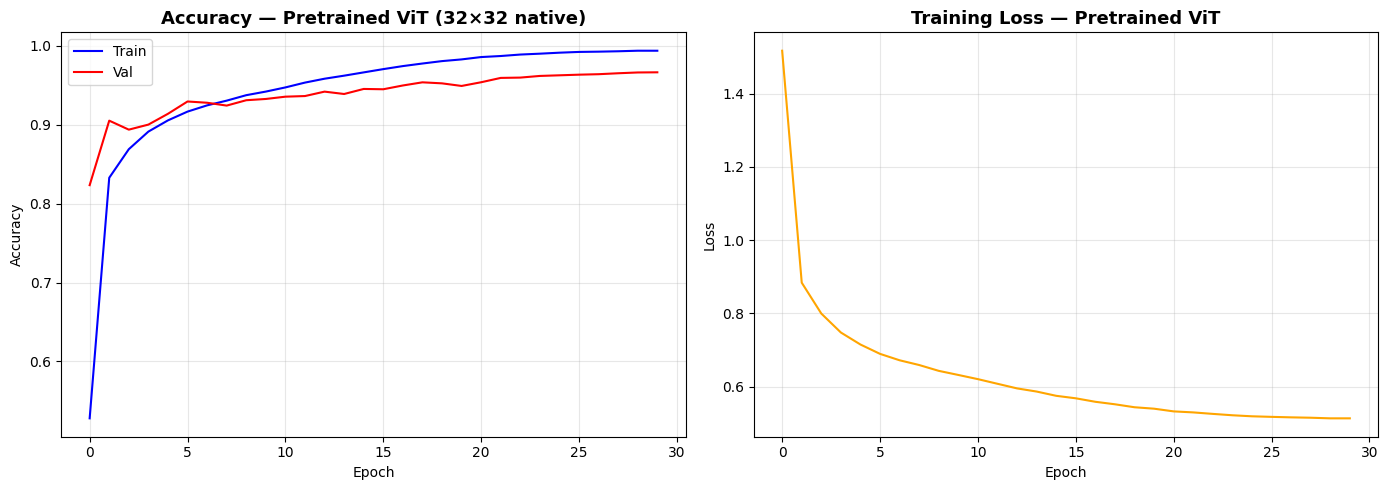

In [ ]:
# ── TRAINING CURVES ───────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(train_accs, label='Train', color='blue')
ax1.plot(val_accs,   label='Val',   color='red')
ax1.set_title('Accuracy — Pretrained ViT (32×32 native)', fontsize=13, fontweight='bold')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Accuracy')
ax1.legend(); ax1.grid(True, alpha=0.3)

ax2.plot(train_losses, color='orange')
ax2.set_title('Training Loss — Pretrained ViT', fontsize=13, fontweight='bold')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Loss')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('__4__training_curves.png', dpi=150)
plt.show()

In [ ]:
# ── FULL EVALUATION ───────────────────────────────────────────
print("\n" + "="*60)
print("FULL EVALUATION")
print("="*60)

model.load_state_dict(torch.load(SAVE_PATH, map_location=DEVICE))
model.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(DEVICE)
        preds  = model(inputs).argmax(1).cpu()
        all_preds.extend(preds.numpy())
        all_labels.extend(labels.numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)

acc       = accuracy_score(all_labels, all_preds)
precision = precision_score(all_labels, all_preds, average='macro')
recall    = recall_score(all_labels, all_preds, average='macro')
f1        = f1_score(all_labels, all_preds, average='macro')

print(f"\n  Accuracy          : {acc:.4f}  ({acc*100:.2f}%)")
print(f"  Precision (macro) : {precision:.4f}")
print(f"  Recall    (macro) : {recall:.4f}")
print(f"  F1-score  (macro) : {f1:.4f}")
print("\nPer-class report:")
print(classification_report(all_labels, all_preds,
                             target_names=CIFAR10_CLASSES, digits=4))


FULL EVALUATION

  Accuracy          : 0.9666  (96.66%)
  Precision (macro) : 0.9667
  Recall    (macro) : 0.9666
  F1-score  (macro) : 0.9666

Per-class report:
              precision    recall  f1-score   support

    airplane     0.9819    0.9780    0.9800      1000
  automobile     0.9742    0.9800    0.9771      1000
        bird     0.9706    0.9560    0.9632      1000
         cat     0.9231    0.9240    0.9235      1000
        deer     0.9670    0.9680    0.9675      1000
         dog     0.9318    0.9420    0.9368      1000
        frog     0.9762    0.9830    0.9796      1000
       horse     0.9869    0.9800    0.9834      1000
        ship     0.9830    0.9840    0.9835      1000
       truck     0.9720    0.9710    0.9715      1000

    accuracy                         0.9666     10000
   macro avg     0.9667    0.9666    0.9666     10000
weighted avg     0.9667    0.9666    0.9666     10000



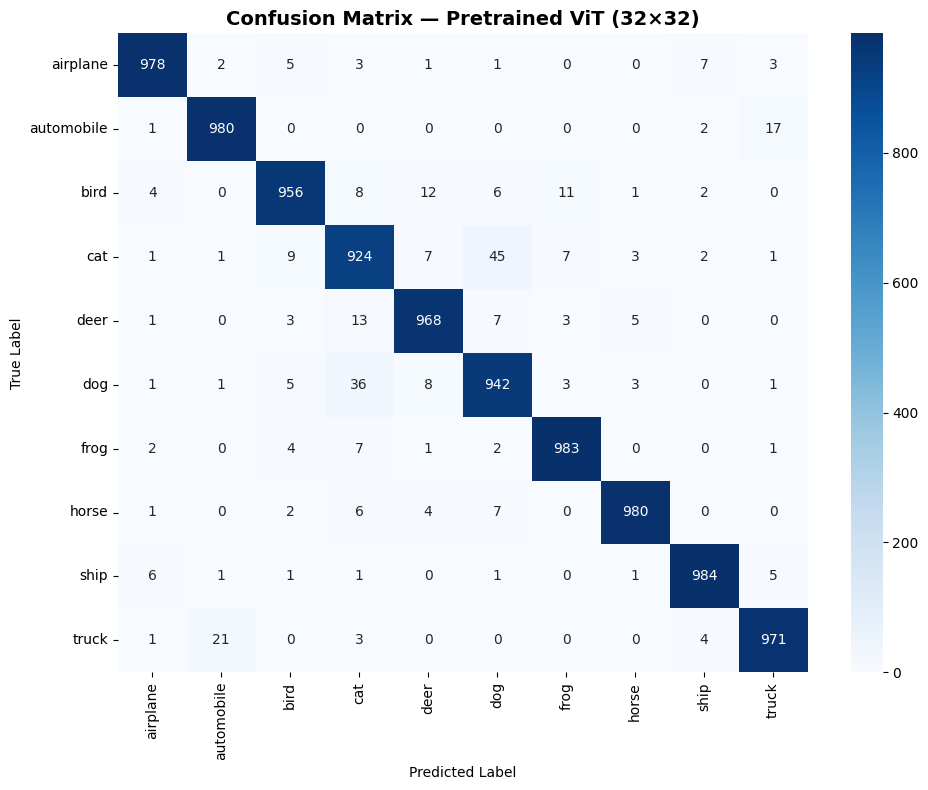

In [ ]:
# ── CONFUSION MATRIX ──────────────────────────────────────────
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CIFAR10_CLASSES, yticklabels=CIFAR10_CLASSES)
plt.title('Confusion Matrix — Pretrained ViT (32×32)', fontsize=14, fontweight='bold')
plt.ylabel('True Label'); plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('__4__confusion_matrix.png', dpi=150)
plt.show()

In [ ]:
# ── MODEL COMPLEXITY METRICS ──────────────────────────────────
print("\n" + "="*60)
print("MODEL COMPLEXITY METRICS")
print("="*60)

size_mb = os.path.getsize(SAVE_PATH) / 1e6
dummy   = torch.randn(1, 3, IMG_SIZE, IMG_SIZE).to(DEVICE)
macs, _ = profile(model, inputs=(dummy,), verbose=False)
flops   = macs * 2

model.eval()
with torch.no_grad():
    for _ in range(10):
        model(dummy)
    times = []
    for _ in range(200):
        t0 = time.time()
        model(dummy)
        times.append(time.time() - t0)
inf_ms = np.mean(times) * 1000

print(f"  Parameters      : {total_params:,}")
print(f"  Model size      : {size_mb:.2f} MB")
print(f"  FLOPs           : {flops/1e9:.3f} GFLOPs  (at {IMG_SIZE}×{IMG_SIZE})")
print(f"  Inference time  : {inf_ms:.3f} ms  (single image, {IMG_SIZE}×{IMG_SIZE})")


MODEL COMPLEXITY METRICS
  Parameters      : 21,342,346
  Model size      : 85.43 MB
  FLOPs           : 2.763 GFLOPs  (at 32×32)
  Inference time  : 4.534 ms  (single image, 32×32)


In [ ]:
# ── SAVE METRICS JSON ─────────────────────────────────────────
baseline_metrics = {
    "accuracy"    : acc,
    "precision"   : precision,
    "recall"      : recall,
    "f1"          : f1,
    "params"      : total_params,
    "size_mb"     : size_mb,
    "flops_G"     : flops / 1e9,
    "inference_ms": inf_ms,
    "input_resolution": IMG_SIZE,
    "patch_size"  : 4,
    "num_patches" : 64,
    "pretrained"  : "ImageNet-21k (vit_small_patch16_224 via timm, pos_embed interpolated)",
}
with open("__4__baseline_metrics.json", "w") as f:
    json.dump(baseline_metrics, f, indent=2)
print("\n✓ Metrics saved to __4__baseline_metrics.json")


✓ Metrics saved to __4__baseline_metrics.json


In [ ]:
# ── PREDICT ON CUSTOM IMAGES ──────────────────────────────────
predict_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(CIFAR_MEAN, CIFAR_STD),
])

def predict_image(image_path, model, show=True):
    img    = Image.open(image_path).convert('RGB')
    tensor = predict_transform(img).unsqueeze(0).to(DEVICE)

    model.eval()
    with torch.no_grad():
        probs = torch.softmax(model(tensor), dim=1).squeeze().cpu().numpy()

    pred_idx   = probs.argmax()
    pred_class = CIFAR10_CLASSES[pred_idx]
    confidence = probs[pred_idx]

    if show:
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
        ax1.imshow(img)
        ax1.set_title(f"Prediction: {pred_class}\nConfidence: {confidence:.2%}",
                      fontsize=12, fontweight='bold')
        ax1.axis('off')

        colors = ['crimson' if i == pred_idx else 'steelblue' for i in range(NUM_CLASSES)]
        ax2.barh(CIFAR10_CLASSES, probs, color=colors)
        ax2.set_xlabel('Probability')
        ax2.set_title('Class Probabilities')
        ax2.set_xlim(0, 1)
        for i, v in enumerate(probs):
            ax2.text(v + 0.01, i, f'{v:.1%}', va='center', fontsize=9)
        plt.tight_layout()
        plt.savefig(f'pred_{os.path.splitext(os.path.basename(image_path))[0]}.png', dpi=150)
        plt.show()

    top3 = sorted(zip(CIFAR10_CLASSES, probs), key=lambda x: -x[1])[:3]
    print(f"  File      : {os.path.basename(image_path)}")
    print(f"  Predicted : {pred_class} ({confidence:.2%})")
    print(f"  Top-3     : {[(c, f'{p:.2%}') for c, p in top3]}\n")
    return pred_class, probs


def predict_folder(folder_path, model, save_json=True):
    supported = ('.jpg', '.jpeg', '.png', '.bmp', '.webp')
    files = [f for f in os.listdir(folder_path) if f.lower().endswith(supported)]
    if not files:
        print(f"No images found in {folder_path}")
        return
    print(f"\n{'File':<35} {'Prediction':<15} {'Confidence':>10}")
    print("-" * 62)
    results = []
    for fname in sorted(files):
        pred_class, probs = predict_image(os.path.join(folder_path, fname),
                                          model, show=False)
        conf = float(probs.max())
        results.append((fname, pred_class, conf))
        print(f"  {fname:<33} {pred_class:<15} {conf:>9.2%}")
        print("─" * 72)

    if save_json:
        with open("__4__output_on_test_data.json", "w") as f:
            json.dump(results, f, indent=4)
    return results


# predict_folder("./data_test/", model)

  Pretrained weights transferred : 149 tensors
  Re-initialised (shape mismatch): 3 tensors (patch_embed + pos_embed)
  Classifier head                : Linear(in_features=384, out_features=10, bias=True)
  Positional embeddings          : torch.Size([1, 65, 384])  (1 CLS + 64 patches)

Sample 1 — True label: cat


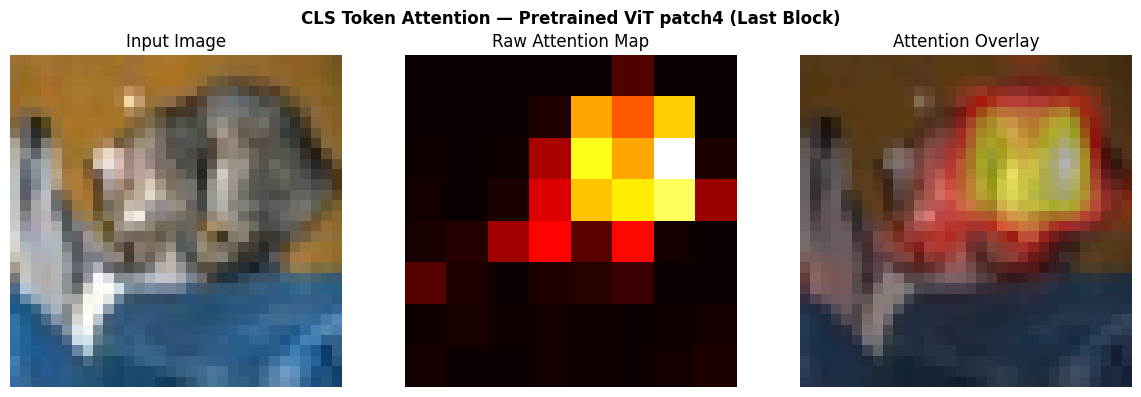

✓ Attention map saved to __4__attention_sample_1.png

Sample 2 — True label: ship


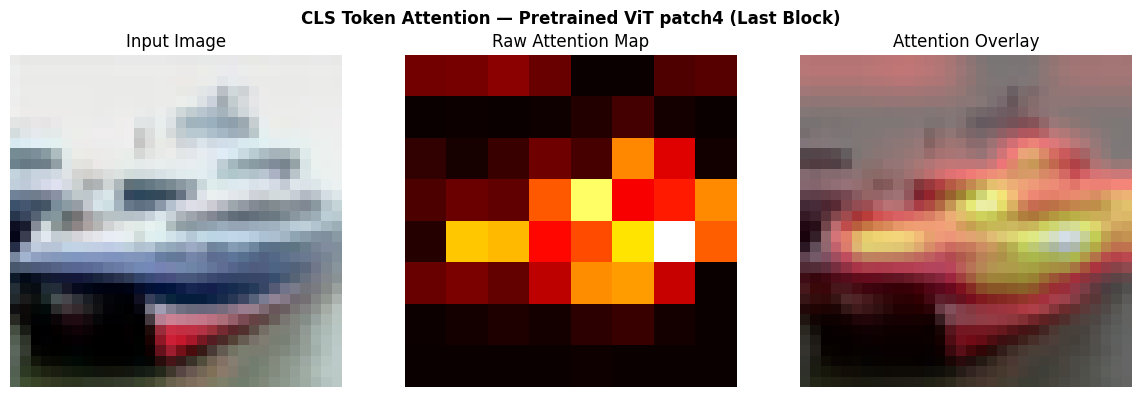

✓ Attention map saved to __4__attention_sample_2.png

Sample 3 — True label: ship


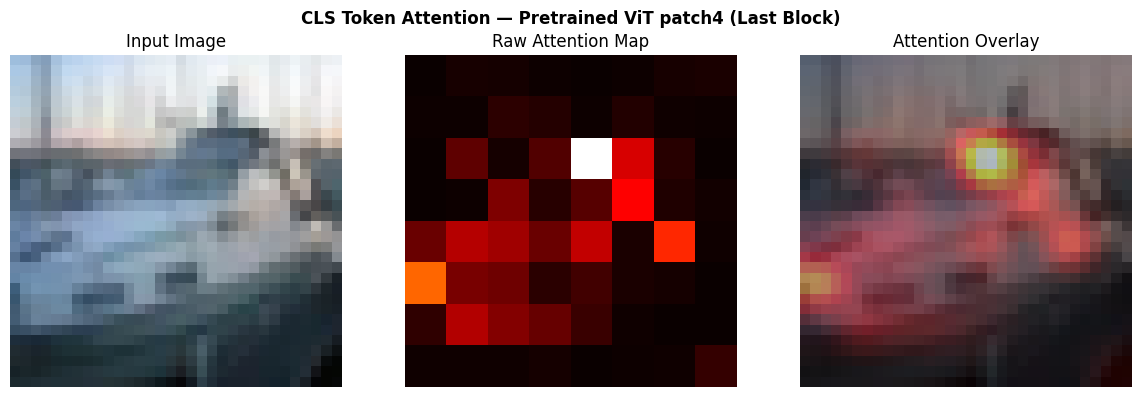

✓ Attention map saved to __4__attention_sample_3.png


In [ ]:
# ── ATTENTION MAP VISUALISATION ───────────────────────────────
# Adapted for 32×32 native resolution: patch grid is 8×8 (not 14×14)

def visualise_attention(model, image_tensor, save_path="__4__attention_map.png"):
    """
    Extracts CLS-token attention from the last transformer block.
    Works with the 32×32 patch_size=4 adapted model (8×8 patch grid).
    """
    model.eval()
    x = image_tensor.unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        x_emb = model.patch_embed(x)                        # (1, 64, D)
        cls   = model.cls_token.expand(1, -1, -1)           # (1,  1, D)
        x_emb = torch.cat([cls, x_emb], dim=1)              # (1, 65, D)
        x_emb = model.pos_drop(x_emb + model.pos_embed)

        for blk in model.blocks[:-1]:
            x_emb = blk(x_emb)

        last_blk = model.blocks[-1]
        x_norm   = last_blk.norm1(x_emb)
        B, N, C  = x_norm.shape

        qkv = (last_blk.attn.qkv(x_norm)
                   .reshape(B, N, 3, last_blk.attn.num_heads,
                            C // last_blk.attn.num_heads)
                   .permute(2, 0, 3, 1, 4))
        q, k, _ = qkv.unbind(0)
        scale = (C // last_blk.attn.num_heads) ** -0.5
        attn  = (q @ k.transpose(-2, -1)) * scale
        attn  = attn.softmax(dim=-1)

    # CLS → patch attention, averaged over heads: 64 patches → 8×8
    cls_attn = attn[0, :, 0, 1:].mean(dim=0)   # (64,)
    n        = int(cls_attn.shape[0] ** 0.5)    # 8
    attn_map = cls_attn.reshape(n, n).cpu().numpy()

    from PIL import Image as PILImage
    attn_img = PILImage.fromarray(
        (attn_map / attn_map.max() * 255).astype(np.uint8)
    ).resize((IMG_SIZE, IMG_SIZE), PILImage.BILINEAR)

    img_np = image_tensor.permute(1, 2, 0).numpy()
    img_np = (img_np * np.array(CIFAR_STD) + np.array(CIFAR_MEAN)).clip(0, 1)

    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    axes[0].imshow(img_np);               axes[0].set_title('Input Image');        axes[0].axis('off')
    axes[1].imshow(attn_map, cmap='hot'); axes[1].set_title('Raw Attention Map');  axes[1].axis('off')
    axes[2].imshow(img_np)
    axes[2].imshow(np.array(attn_img), cmap='hot', alpha=0.5)
    axes[2].set_title('Attention Overlay'); axes[2].axis('off')

    plt.suptitle('CLS Token Attention — Pretrained ViT patch4 (Last Block)', fontweight='bold')
    plt.tight_layout()
    plt.savefig(save_path, dpi=150)
    plt.show()
    print(f"✓ Attention map saved to {save_path}")


model = build_model(NUM_CLASSES).to(DEVICE)
state_dict = torch.load(SAVE_PATH, map_location=DEVICE)
model.load_state_dict(state_dict)

# model.load_state_dict(torch.load(SAVE_PATH, map_location=DEVICE))

test_imgs, test_labels = next(iter(test_loader))
for i in range(3):
    print(f"\nSample {i+1} — True label: {CIFAR10_CLASSES[test_labels[i]]}")
    visualise_attention(model, test_imgs[i],
                        save_path=f"__4__attention_sample_{i+1}.png")


In [ ]:
# ── SAVE FULL CHECKPOINT ──────────────────────────────────────
config_dict = {
    "model_name"  : "vit_small_patch4_32_pretrained",
    "timm_model"  : "vit_small_patch16_224",
    "pretrained"  : "ImageNet-21k (pos_embed interpolated 14×14 → 8×8)",
    "img_size"    : IMG_SIZE,
    "patch_size"  : 4,
    "num_patches" : 64,
    "num_classes" : NUM_CLASSES,
    "input_size"  : [3, IMG_SIZE, IMG_SIZE],
    "normalization": {
        "mean": CIFAR_MEAN,
        "std" : CIFAR_STD,
    },
    "training": {
        "batch_size"     : BATCH_SIZE,
        "epochs"         : EPOCHS,
        "learning_rate"  : LR,
        "patch_embed_lr" : LR * 10,
        "optimizer"      : "AdamW",
        "weight_decay"   : 0.05,
        "scheduler"      : "WarmupCosine",
        "warmup_epochs"  : WARMUP_EPOCHS,
        "grad_clip"      : 1.0,
        "label_smoothing": 0.1,
    }
}

torch.save({
    "model_state_dict": model.state_dict(),
    "config"          : config_dict,
    "classes"         : CIFAR10_CLASSES,
}, "__4__model_checkpoint.pth")

print("\n" + "="*60)
print("BASELINE COMPLETE — Pretrained ViT (native 32×32, patch_size=4)")
print("="*60)
print(f"  Weights    → {SAVE_PATH}")
print(f"  Checkpoint → __4__model_checkpoint.pth")
print(f"  Metrics    → __4__baseline_metrics.json")
print(f"  Plots      → __4__training_curves.png")
print(f"               __4__confusion_matrix.png")
print(f"               __4__attention_sample_1/2/3.png")


BASELINE COMPLETE — Pretrained ViT (native 32×32, patch_size=4)
  Weights    → __4__baseline_vit_pretrained_cifar10.pth
  Checkpoint → __4__model_checkpoint.pth
  Metrics    → __4__baseline_metrics.json
  Plots      → __4__training_curves.png
               __4__confusion_matrix.png
               __4__attention_sample_1/2/3.png


In [ ]:
# ── LOADING THE MODEL (reference) ────────────────────────────
# checkpoint = torch.load("__4__model_checkpoint.pth", map_location="cpu")
# config     = checkpoint["config"]
# classes    = checkpoint["classes"]
#
# model = timm.create_model(
#     config["timm_model"],
#     pretrained=False,
#     num_classes=config["num_classes"],
#     img_size=config["img_size"],
#     patch_size=config["patch_size"],
# )
# model.load_state_dict(checkpoint["model_state_dict"])
# model.eval()